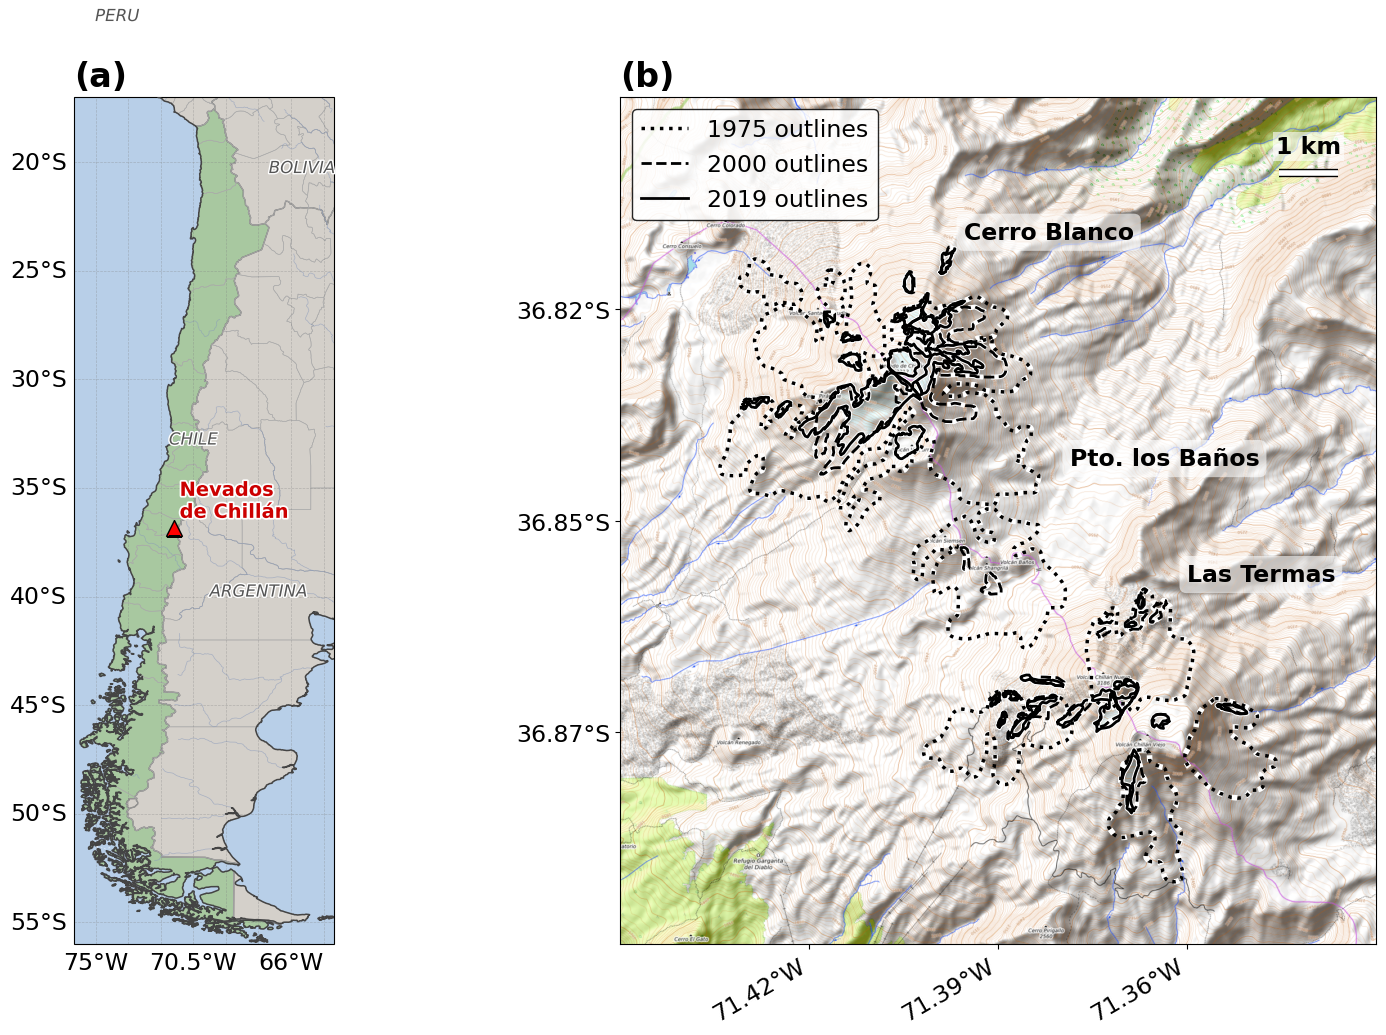

Saved: fig01_study_area.png


In [1]:
# ==============================================================================
# Fig 1: Study area — Chile overview + zoomed complex
# Publication quality
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
import numpy as np
import geopandas as gpd
import contextily as ctx
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.patches import Rectangle
import os

SHP = {
    '1975': '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp',
    '2000': '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp',
    '2019': '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp',
}
FIGURES = '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures'
os.makedirs(FIGURES, exist_ok=True)

CERRO_BLANCO_GLACIERS = [
    'CL108101050','CL108105002','CL108101048','CL108116003','CL108116002',
    'CL108116001','CL108116005','CL108116006','CL108116004','CL108101049','CL108105003'
]
LASTERMAS_GLACIERS = [
    'CL108130010','CL108100003','CL108100002','CL108100004','CL108130008',
    'CL108130003','CL108130007','CL108130006','CL108130005','CL108130004',
    'CL108100005','CL108100006','CL108101047','CL108101046','CL108130009'
]
SADDLE_GLACIERS = ['CL108130002','CL108130001']

# ── Publication-quality font settings ─────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':         20,
    'axes.titlesize':    22,
    'axes.labelsize':    20,
    'xtick.labelsize':   18,
    'ytick.labelsize':   18,
    'legend.fontsize':   18,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

NDC_LON, NDC_LAT = -71.38, -36.86

# Load outlines
gdf_1975_sa = gpd.read_file(SHP['1975']).to_crs('EPSG:3857')
gdf_2000_sa = gpd.read_file(SHP['2000']).to_crs('EPSG:3857')
gdf_2019_sa = gpd.read_file(SHP['2019']).to_crs('EPSG:3857')
gdf_2019_sa['COD_GLA'] = gdf_2019_sa['COD_GLA'].str.rstrip('@')

# Panel (b) extent — shifted north so legend doesn't cover outlines
_b     = gdf_1975_sa.total_bounds
_pad_x = (_b[2] - _b[0]) * 0.18
_pad_y = (_b[3] - _b[1]) * 0.18
xlim_b = (_b[0] - _pad_x, _b[2] + _pad_x)
_h_raw = _b[3] - _b[1]
_shift_n = _h_raw * 0.08
ylim_b = (_b[1] - _pad_y + _shift_n, _b[3] + _pad_y + _shift_n)

_tr     = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
lon_min = _tr.transform(xlim_b[0], ylim_b[0])[0]
lon_max = _tr.transform(xlim_b[1], ylim_b[1])[0]
lat_min = _tr.transform(xlim_b[0], ylim_b[0])[1]
lat_max = _tr.transform(xlim_b[1], ylim_b[1])[1]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11))
ax_a = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_b = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(wspace=0.05)

# ── Panel (a): Chile overview ─────────────────────────────────────────────────
ax_a.set_extent([-76, -64, -56, -17], crs=ccrs.PlateCarree())
ax_a.add_feature(cfeature.OCEAN, facecolor='#b8cfe8', zorder=0)

shpfile = shpreader.natural_earth(resolution='10m',
                                   category='cultural',
                                   name='admin_0_countries')
for rec in shpreader.Reader(shpfile).records():
    color = '#a8c8a0' if rec.attributes['NAME'] == 'Chile' else '#d4d0ca'
    ax_a.add_geometries([rec.geometry], ccrs.PlateCarree(),
                         facecolor=color, edgecolor='none', zorder=1)

ax_a.add_feature(cfeature.BORDERS,   linewidth=1.0, edgecolor='#777777', zorder=2)
ax_a.add_feature(cfeature.COASTLINE, linewidth=1.1, edgecolor='#444444', zorder=3)

provinces = cfeature.NaturalEarthFeature(
    'cultural', 'admin_1_states_provinces', '10m',
    facecolor='none', edgecolor='#aaaaaa', linewidth=0.4)
ax_a.add_feature(provinces, zorder=2)
ax_a.add_feature(cfeature.RIVERS, linewidth=0.5,
                  edgecolor='#8899bb', alpha=0.6, zorder=2)

# Study area rectangle
rect = Rectangle((lon_min, lat_min),
                  lon_max - lon_min, lat_max - lat_min,
                  linewidth=2.5, edgecolor='red', facecolor='#ff000033',
                  transform=ccrs.PlateCarree(), zorder=5)
ax_a.add_patch(rect)

# Volcano marker
ax_a.plot(NDC_LON, NDC_LAT, marker='^', color='red', markersize=12,
          transform=ccrs.PlateCarree(), zorder=6,
          markeredgecolor='black', markeredgewidth=1.0)

# Label close to triangle
ax_a.text(NDC_LON + 0.25, NDC_LAT + 0.3, 'Nevados\nde Chillán',
          transform=ccrs.PlateCarree(), fontsize=14, color='#cc0000',
          fontweight='bold', ha='left', va='bottom',
          path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# Country labels
for name, lon, lat in [
    ('CHILE',     -70.5, -33.0),
    ('ARGENTINA', -67.5, -40.0),
    ('BOLIVIA',   -65.5, -20.5),
    ('PERU',      -74.0, -13.5),
]:
    ax_a.text(lon, lat, name, transform=ccrs.PlateCarree(),
              fontsize=12, color='#555555', ha='center', style='italic',
              path_effects=[pe.withStroke(linewidth=2, foreground='white')])

gl = ax_a.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                     linewidth=0.5, color='gray', alpha=0.4,
                     linestyle='--', zorder=3)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 17}
gl.ylabel_style = {'size': 17}

ax_a.set_title('(a)', fontsize=24, fontweight='bold', loc='left', pad=8)

# ── Panel (b): Zoomed complex ─────────────────────────────────────────────────
ax_b.set_xlim(xlim_b)
ax_b.set_ylim(ylim_b)

try:
    ctx.add_basemap(ax_b, crs='EPSG:3857',
                    source=ctx.providers.OpenTopoMap,
                    zoom=14, attribution=False)
except Exception as e:
    print(f'Basemap failed: {e}')

# Outlines — black with white halo, matching Figs 3/4
OUTLINE_STYLES_SA = [
    (gdf_1975_sa, 2.5, ':',  '1975 outlines'),
    (gdf_2000_sa, 2.0, '--', '2000 outlines'),
    (gdf_2019_sa, 2.0, '-',  '2019 outlines'),
]
for gdf, lw, ls, label in OUTLINE_STYLES_SA:
    plotted = False
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in polys:
            # White halo underneath
            ax_b.plot(*poly.exterior.xy, color='white', lw=lw+1.5, ls=ls,
                      label='_nolegend_', zorder=4)
            # Black line on top
            ax_b.plot(*poly.exterior.xy, color='black', lw=lw, ls=ls,
                      label=label if not plotted else '_nolegend_', zorder=5)
            plotted = True

# Subcomplex labels
_w = xlim_b[1] - xlim_b[0]
_h = ylim_b[1] - ylim_b[0]
dx = _w * 0.12
dy = _h * 0.12

for name, ids in [
    ('Cerro Blanco',   CERRO_BLANCO_GLACIERS),
    ('Las Termas',     LASTERMAS_GLACIERS),
    ('Pto. los Baños', SADDLE_GLACIERS),
]:
    gdf_sub = gdf_2000_sa[gdf_2000_sa['COD_GLA'].isin(ids)]
    if len(gdf_sub) == 0:
        continue
    cx = gdf_sub.geometry.centroid.x.mean()
    cy = gdf_sub.geometry.centroid.y.mean()
    ax_b.text(
        cx + dx, cy + dy, name,
        fontsize=17, fontweight='bold', color='black',
        ha='left', va='bottom', zorder=9,
        bbox=dict(facecolor='white', alpha=0.6, pad=3,
                  edgecolor='none', boxstyle='round,pad=0.3'),
    )

# Lat/lon ticks
_to_ll  = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
xtv     = np.linspace(xlim_b[0], xlim_b[1], 5)[1:-1]
ytv     = np.linspace(ylim_b[0], ylim_b[1], 5)[1:-1]
y_mid_b = (ylim_b[0] + ylim_b[1]) / 2
x_mid_b = (xlim_b[0] + xlim_b[1]) / 2
xlons_b = [_to_ll.transform(x, y_mid_b)[0] for x in xtv]
ylats_b = [_to_ll.transform(x_mid_b, y)[1] for y in ytv]
ax_b.set_xticks(xtv)
ax_b.set_yticks(ytv)
ax_b.set_xticklabels([f'{abs(lon):.2f}°{"W" if lon<0 else "E"}'
                       for lon in xlons_b], fontsize=17, rotation=30, ha='right')
ax_b.set_yticklabels([f'{abs(lat):.2f}°{"S" if lat<0 else "N"}'
                       for lat in ylats_b], fontsize=17)

# Scale bar
x1_bar = xlim_b[0] + _w * 0.95
x0_bar = x1_bar - 1000
y_bar  = ylim_b[0] + _h * 0.91
ax_b.plot([x0_bar, x1_bar], [y_bar, y_bar],
          color='black', lw=6, solid_capstyle='butt', zorder=5)
ax_b.plot([x0_bar, x1_bar], [y_bar, y_bar],
          color='white', lw=4, solid_capstyle='butt', zorder=6)
ax_b.text((x0_bar + x1_bar) / 2, y_bar + _h * 0.018,
          '1 km', color='black', ha='center', va='bottom',
          fontsize=17, fontweight='bold', zorder=7,
          bbox=dict(facecolor='white', alpha=0.6, pad=2, edgecolor='none'))

# Legend
handles_b = [
    mlines.Line2D([0],[0], color='black', lw=2.5, ls=':', label='1975 outlines'),
    mlines.Line2D([0],[0], color='black', lw=2.0, ls='--', label='2000 outlines'),
    mlines.Line2D([0],[0], color='black', lw=2.0, ls='-',  label='2019 outlines'),
]
ax_b.legend(handles=handles_b, loc='upper left', fontsize=17,
            framealpha=0.85, facecolor='white',
            edgecolor='black', labelcolor='black')

ax_b.set_title('(b)', fontsize=24, fontweight='bold', loc='left', pad=8)

fig.savefig(os.path.join(FIGURES, 'fig01_study_area.png'),
            dpi=600, bbox_inches='tight')
plt.show()
print('Saved: fig01_study_area.png')

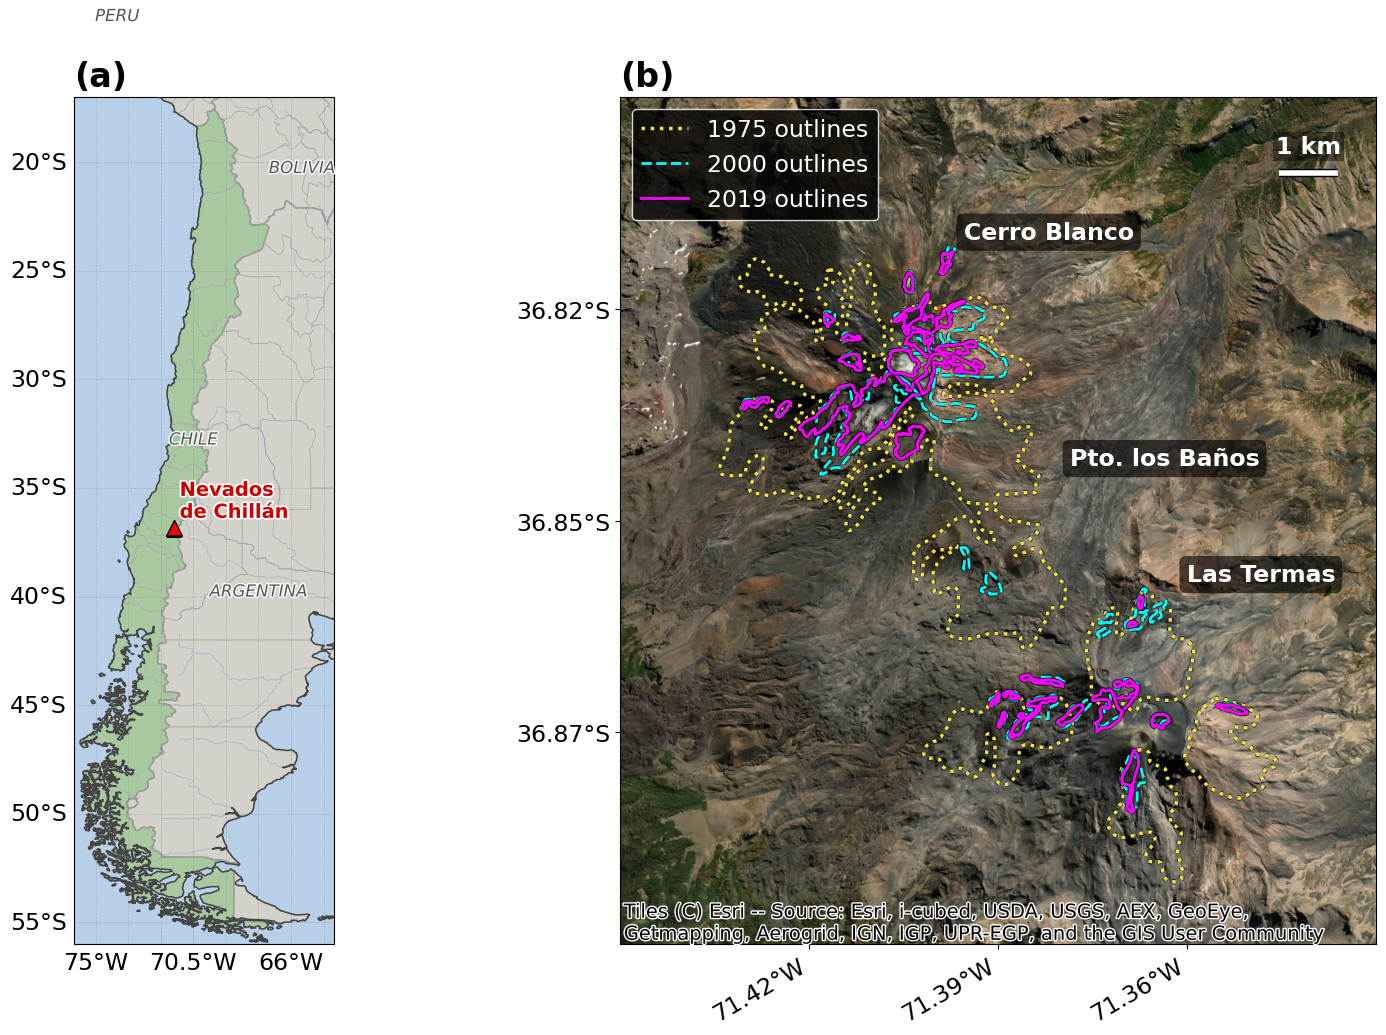

Saved: fig01_study_area.png


In [11]:
# ==============================================================================
# Fig 1: Study area — Chile overview + zoomed complex
# Publication quality
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
import numpy as np
import geopandas as gpd
import contextily as ctx
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.patches import Rectangle
import os

SHP = {
    '1975': '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp',
    '2000': '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp',
    '2019': '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp',
}
FIGURES = '/Users/milliespencer/Glacier-DEM-coregistration-and-MB/figures'
os.makedirs(FIGURES, exist_ok=True)

CERRO_BLANCO_GLACIERS = [
    'CL108101050','CL108105002','CL108101048','CL108116003','CL108116002',
    'CL108116001','CL108116005','CL108116006','CL108116004','CL108101049','CL108105003'
]
LASTERMAS_GLACIERS = [
    'CL108130010','CL108100003','CL108100002','CL108100004','CL108130008',
    'CL108130003','CL108130007','CL108130006','CL108130005','CL108130004',
    'CL108100005','CL108100006','CL108101047','CL108101046','CL108130009'
]
SADDLE_GLACIERS = ['CL108130002','CL108130001']

# ── Outline colors ────────────────────────────────────────────────────────────
COLOR_1975 = '#F0E442'  # yellow
COLOR_2000 = '#00FFFF'  # cyan
COLOR_2019 = '#FF00FF'  # magenta

# ── Publication-quality font settings ─────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':         20,
    'axes.titlesize':    22,
    'axes.labelsize':    20,
    'xtick.labelsize':   18,
    'ytick.labelsize':   18,
    'legend.fontsize':   18,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

NDC_LON, NDC_LAT = -71.38, -36.86

# Load outlines
gdf_1975_sa = gpd.read_file(SHP['1975']).to_crs('EPSG:3857')
gdf_2000_sa = gpd.read_file(SHP['2000']).to_crs('EPSG:3857')
gdf_2019_sa = gpd.read_file(SHP['2019']).to_crs('EPSG:3857')
gdf_2019_sa['COD_GLA'] = gdf_2019_sa['COD_GLA'].str.rstrip('@')

# Panel (b) extent — shifted north so legend doesn't cover outlines
_b     = gdf_1975_sa.total_bounds
_pad_x = (_b[2] - _b[0]) * 0.18
_pad_y = (_b[3] - _b[1]) * 0.18
xlim_b = (_b[0] - _pad_x, _b[2] + _pad_x)
_h_raw = _b[3] - _b[1]
_shift_n = _h_raw * 0.08
ylim_b = (_b[1] - _pad_y + _shift_n, _b[3] + _pad_y + _shift_n)

_tr     = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
lon_min = _tr.transform(xlim_b[0], ylim_b[0])[0]
lon_max = _tr.transform(xlim_b[1], ylim_b[1])[0]
lat_min = _tr.transform(xlim_b[0], ylim_b[0])[1]
lat_max = _tr.transform(xlim_b[1], ylim_b[1])[1]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11))
ax_a = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_b = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(wspace=0.05)

# ── Panel (a): Chile overview ─────────────────────────────────────────────────
ax_a.set_extent([-76, -64, -56, -17], crs=ccrs.PlateCarree())
ax_a.add_feature(cfeature.OCEAN, facecolor='#b8cfe8', zorder=0)

shpfile = shpreader.natural_earth(resolution='10m',
                                   category='cultural',
                                   name='admin_0_countries')
for rec in shpreader.Reader(shpfile).records():
    color = '#a8c8a0' if rec.attributes['NAME'] == 'Chile' else '#d4d0ca'
    ax_a.add_geometries([rec.geometry], ccrs.PlateCarree(),
                         facecolor=color, edgecolor='none', zorder=1)

ax_a.add_feature(cfeature.BORDERS,   linewidth=1.0, edgecolor='#777777', zorder=2)
ax_a.add_feature(cfeature.COASTLINE, linewidth=1.1, edgecolor='#444444', zorder=3)

provinces = cfeature.NaturalEarthFeature(
    'cultural', 'admin_1_states_provinces', '10m',
    facecolor='none', edgecolor='#aaaaaa', linewidth=0.4)
ax_a.add_feature(provinces, zorder=2)
ax_a.add_feature(cfeature.RIVERS, linewidth=0.5,
                  edgecolor='#8899bb', alpha=0.6, zorder=2)

# Study area rectangle
rect = Rectangle((lon_min, lat_min),
                  lon_max - lon_min, lat_max - lat_min,
                  linewidth=2.5, edgecolor='red', facecolor='#ff000033',
                  transform=ccrs.PlateCarree(), zorder=5)
ax_a.add_patch(rect)

# Volcano marker
ax_a.plot(NDC_LON, NDC_LAT, marker='^', color='red', markersize=12,
          transform=ccrs.PlateCarree(), zorder=6,
          markeredgecolor='black', markeredgewidth=1.0)

# Label close to triangle
ax_a.text(NDC_LON + 0.25, NDC_LAT + 0.3, 'Nevados\nde Chillán',
          transform=ccrs.PlateCarree(), fontsize=14, color='#cc0000',
          fontweight='bold', ha='left', va='bottom',
          path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

# Country labels — all within [-76, -64] map extent
for name, lon, lat in [
    ('CHILE',     -70.5, -33.0),
    ('ARGENTINA', -67.5, -40.0),
    ('BOLIVIA',   -65.5, -20.5),
    ('PERU',      -74.0, -13.5),
]:
    ax_a.text(lon, lat, name, transform=ccrs.PlateCarree(),
              fontsize=12, color='#555555', ha='center', style='italic',
              path_effects=[pe.withStroke(linewidth=2, foreground='white')])

gl = ax_a.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                     linewidth=0.5, color='gray', alpha=0.4,
                     linestyle='--', zorder=3)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 17}
gl.ylabel_style = {'size': 17}

ax_a.set_title('(a)', fontsize=24, fontweight='bold', loc='left', pad=8)

# ── Panel (b): Zoomed complex ─────────────────────────────────────────────────
ax_b.set_xlim(xlim_b)
ax_b.set_ylim(ylim_b)

try:
    ctx.add_basemap(ax_b, crs='EPSG:3857',
                source=ctx.providers.Esri.WorldImagery, zoom=14,
                attribution_size=14)
except Exception as e:
    print(f'Basemap failed: {e}')

# Outlines
OUTLINE_STYLES_SA = [
    (gdf_1975_sa, COLOR_1975, 2.5, ':',  '1975 outlines'),
    (gdf_2000_sa, COLOR_2000, 2.0, '--', '2000 outlines'),
    (gdf_2019_sa, COLOR_2019, 2.0, '-',  '2019 outlines'),
]
for gdf, color, lw, ls, label in OUTLINE_STYLES_SA:
    plotted = False
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in polys:
            ax_b.plot(*poly.exterior.xy, color=color, lw=lw, ls=ls,
                      label=label if not plotted else '_nolegend_',
                      path_effects=[pe.withStroke(linewidth=lw + 1.5,
                                                   foreground='black',
                                                   alpha=0.6)])
            plotted = True

# Subcomplex labels
_w = xlim_b[1] - xlim_b[0]
_h = ylim_b[1] - ylim_b[0]
dx = _w * 0.12
dy = _h * 0.12

for name, ids in [
    ('Cerro Blanco',   CERRO_BLANCO_GLACIERS),
    ('Las Termas',     LASTERMAS_GLACIERS),
    ('Pto. los Baños', SADDLE_GLACIERS),
]:
    gdf_sub = gdf_2000_sa[gdf_2000_sa['COD_GLA'].isin(ids)]
    if len(gdf_sub) == 0:
        continue
    cx = gdf_sub.geometry.centroid.x.mean()
    cy = gdf_sub.geometry.centroid.y.mean()
    ax_b.text(
        cx + dx, cy + dy, name,
        fontsize=17, fontweight='bold', color='white',
        ha='left', va='bottom', zorder=9,
        bbox=dict(facecolor='black', alpha=0.6, pad=3,
                  edgecolor='none', boxstyle='round,pad=0.3'),
    )

# Lat/lon ticks
_to_ll  = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
xtv     = np.linspace(xlim_b[0], xlim_b[1], 5)[1:-1]
ytv     = np.linspace(ylim_b[0], ylim_b[1], 5)[1:-1]
y_mid_b = (ylim_b[0] + ylim_b[1]) / 2
x_mid_b = (xlim_b[0] + xlim_b[1]) / 2
xlons_b = [_to_ll.transform(x, y_mid_b)[0] for x in xtv]
ylats_b = [_to_ll.transform(x_mid_b, y)[1] for y in ytv]
ax_b.set_xticks(xtv)
ax_b.set_yticks(ytv)
ax_b.set_xticklabels([f'{abs(lon):.2f}°{"W" if lon<0 else "E"}'
                       for lon in xlons_b], fontsize=17, rotation=30, ha='right')
ax_b.set_yticklabels([f'{abs(lat):.2f}°{"S" if lat<0 else "N"}'
                       for lat in ylats_b], fontsize=17)

# Scale bar — upper right
x1_bar = xlim_b[0] + _w * 0.95
x0_bar = x1_bar - 1000
y_bar  = ylim_b[0] + _h * 0.91
ax_b.plot([x0_bar, x1_bar], [y_bar, y_bar],
          color='black', lw=6, solid_capstyle='butt', zorder=5)
ax_b.plot([x0_bar, x1_bar], [y_bar, y_bar],
          color='white', lw=4, solid_capstyle='butt', zorder=6)
ax_b.text((x0_bar + x1_bar) / 2, y_bar + _h * 0.018,
          '1 km', color='white', ha='center', va='bottom',
          fontsize=17, fontweight='bold', zorder=7,
          bbox=dict(facecolor='black', alpha=0.4, pad=2, edgecolor='none'))

# Legend — upper left
handles_b = [
    mlines.Line2D([0],[0], color=COLOR_1975, lw=2.5, ls=':', label='1975 outlines'),
    mlines.Line2D([0],[0], color=COLOR_2000, lw=2.0, ls='--', label='2000 outlines'),
    mlines.Line2D([0],[0], color=COLOR_2019, lw=2.0, ls='-',  label='2019 outlines'),
]
ax_b.legend(handles=handles_b, loc='upper left', fontsize=17,
            framealpha=0.80, facecolor='black',
            edgecolor='white', labelcolor='white')

ax_b.set_title('(b)', fontsize=24, fontweight='bold', loc='left', pad=8)

fig.savefig(os.path.join(FIGURES, 'fig01_study_area.png'),
            dpi=600, bbox_inches='tight')
plt.show()
print('Saved: fig01_study_area.png')